# Import  Libs

In [2]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from utils import take_all_bending_setups

# Read pkl file

In [3]:
with open('../../data/experiments_process_and_results.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

# See all available bending setup

In [4]:
all_bending_setups = take_all_bending_setups(loaded_dict)
experiment_number = 60
experiment_as_dictinary = loaded_dict.get(f'Exp_{experiment_number}')
for idx, key in enumerate(list(experiment_as_dictinary.keys())):
    print(f"{idx+1}-{key}")

1-geometry_data_key_characteristics_arc
2-geometry_data_key_characteristics_linear_1
3-geometry_data_key_characteristics_linear_2
4-geometry_data_stl_suitable_arc
5-geometry_data_stl_suitable_linear_1
6-geometry_data_stl_suitable_linear_2
7-process_parameters_loads_machine
8-process_parameters_loads_sensor
9-process_parameters_movements
10-bending_setups


In [18]:
experiment_as_dictinary['geometry_data_key_characteristics_linear_2'].head()

,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm],Tube_Section
96,2.0,22.129342,21.374866,0.034245,-0.656693,LINEAR-2
97,4.0,22.135645,21.387122,0.033975,-0.644436,LINEAR-2
98,6.0,22.153572,21.405191,0.033969,-0.626367,LINEAR-2
99,8.0,22.192398,21.437072,0.034284,-0.594486,LINEAR-2
100,10.0,22.228707,21.486148,0.033704,-0.545410,LINEAR-2


In [ ]:
experiment_as_dictinary['geometry_data_stl_suitable_arc']['Tube_Section'].unique()

array(['LINEAR-1_0', 'LINEAR-1_1', 'LINEAR-1_10', 'LINEAR-1_11',
       'LINEAR-1_12', 'LINEAR-1_13', 'LINEAR-1_14', 'LINEAR-1_15',
       'LINEAR-1_16', 'LINEAR-1_17', 'LINEAR-1_18', 'LINEAR-1_19',
       'LINEAR-1_2', 'LINEAR-1_20', 'LINEAR-1_21', 'LINEAR-1_22',
       'LINEAR-1_23', 'LINEAR-1_24', 'LINEAR-1_25', 'LINEAR-1_26',
       'LINEAR-1_27', 'LINEAR-1_28', 'LINEAR-1_29', 'LINEAR-1_3',
       'LINEAR-1_30', 'LINEAR-1_31', 'LINEAR-1_32', 'LINEAR-1_33',
       'LINEAR-1_34', 'LINEAR-1_35', 'LINEAR-1_36', 'LINEAR-1_37',
       'LINEAR-1_38', 'LINEAR-1_39', 'LINEAR-1_4', 'LINEAR-1_40',
       'LINEAR-1_41', 'LINEAR-1_42', 'LINEAR-1_43', 'LINEAR-1_44',
       'LINEAR-1_45', 'LINEAR-1_46', 'LINEAR-1_47', 'LINEAR-1_48',
       'LINEAR-1_49', 'LINEAR-1_5', 'LINEAR-1_6', 'LINEAR-1_7',
       'LINEAR-1_8', 'LINEAR-1_9'], dtype=object)

# Combine all process parameters

In [6]:
df_machine = experiment_as_dictinary['process_parameters_movements']
df_sensor = experiment_as_dictinary['process_parameters_loads_sensor']
df_movement = experiment_as_dictinary['process_parameters_loads_machine']

# Convert the types of the data to number and also set index

In [7]:
# Ensure 'Time_[s]' is the index for resampling
df_machine['Time_[s]'] = df_machine['Time_[s]'].astype(float)
df_machine.set_index('Time_[s]', inplace=True)
df_machine = df_machine.apply(pd.to_numeric, errors='coerce')
df_sensor['Time_[s]'] = df_sensor['Time_[s]'].astype(float)
df_sensor.set_index('Time_[s]', inplace=True)
df_sensor = df_sensor.apply(pd.to_numeric, errors='coerce')
df_movement['Time_[s]'] = df_movement['Time_[s]'].astype(float)
df_movement.set_index('Time_[s]', inplace=True)
df_movement = df_movement.apply(pd.to_numeric, errors='coerce')

# Resample the times in the datasets that has not good resolution

In [8]:
# Determine the common time range
start_time = max(df.index.min() for df in [df_machine, df_sensor, df_movement])
end_time = min(df.index.max() for df in [df_machine, df_sensor, df_movement])
# Create a common time index with desired frequency (0.01s)
time_index = pd.Index(np.arange(start_time, end_time + 0.01, 0.01), name='Time_[s]')  # use np.arange

In [9]:
# Reindex and interpolate missing values
df_machine_resampled = df_machine.reindex(time_index).interpolate(method='linear')
df_sensor_resampled = df_sensor.reindex(time_index).interpolate(method='linear')
df_movement_resampled = df_movement.reindex(time_index).interpolate(method='linear')

# Concatenate all datasets along columns
df_process_parameters = pd.concat([df_machine_resampled, df_sensor_resampled, df_movement_resampled], axis=1)

# Reset index if you want Time_[s] as a column again
df_process_parameters.reset_index(inplace=True)
df_process_parameters.index = df_process_parameters['Time_[s]']
df_process_parameters.drop(columns=['Time_[s]'], inplace = True)

In [10]:
df_process_parameters.head()   # 8562

,BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],COLLET_ROTATING_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm],PRESSURE-DIE_LEFT_AXIAL_Movement_[mm],...,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]
Time_[s],,,,,,,,,,,,,,,,,,,,,
0.00,-33.0,90.0,19.75,150.0,-289.999908,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.429286,-11.777778,1.375,-1.009333,2.5,0.526316,0.0,11.868002,0.3
0.01,-33.0,90.0,19.75,150.0,-289.999927,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.429572,-11.777778,1.375,-1.009200,2.5,0.526316,0.0,11.849802,0.3
0.02,-33.0,90.0,19.75,150.0,-289.999945,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.429857,-11.777778,1.375,-1.009066,2.5,0.526316,0.0,11.831602,0.3
0.03,-33.0,90.0,19.75,150.0,-289.999963,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.430143,-11.777778,1.375,-1.008933,2.5,0.526316,0.0,11.813402,0.3
0.04,-33.0,90.0,19.75,150.0,-289.999982,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.430429,-11.777778,1.375,-1.008800,2.5,0.526316,0.0,11.795202,0.3


# Normalize and Plot

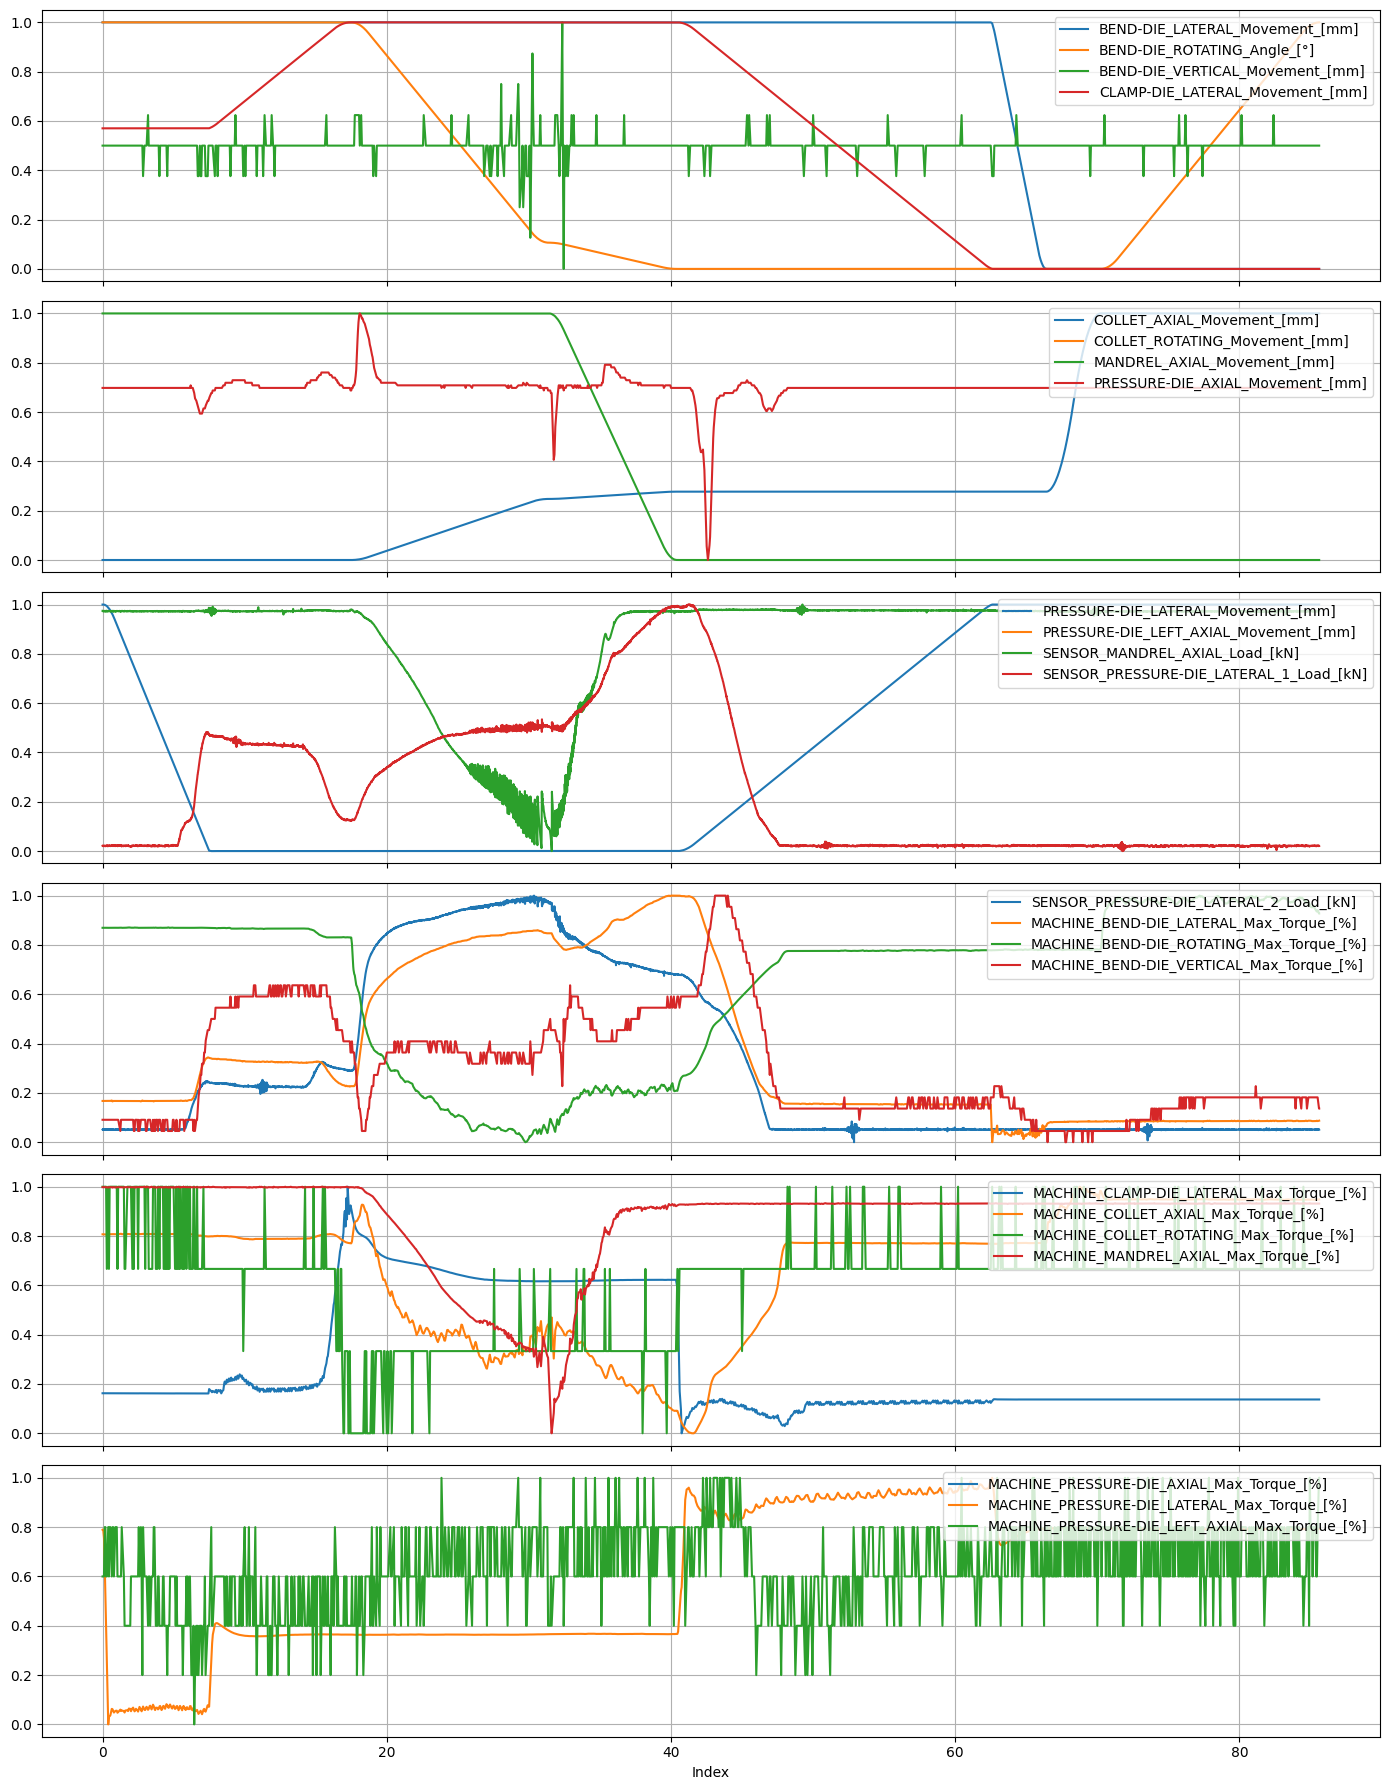

In [11]:
# Normalize the whole dataframe
df_process_parameters_norm = (df_process_parameters - df_process_parameters.min()) / (df_process_parameters.max() - df_process_parameters.min())

# Number of columns per subplot
cols_per_subplot = 4
num_cols = len(df_process_parameters_norm.columns)
num_subplots = int(np.ceil(num_cols / cols_per_subplot))

# Create figure
fig, axes = plt.subplots(nrows=num_subplots, ncols=1, figsize=(14, 3*num_subplots), sharex=True)

# Ensure axes is iterable
if num_subplots == 1:
    axes = [axes]

# Plot columns in groups of 4
for i in range(num_subplots):
    start_col = i * cols_per_subplot
    end_col = start_col + cols_per_subplot
    for j, col in enumerate(df_process_parameters_norm.columns[start_col:end_col]):
        axes[i].plot(df_process_parameters_norm.index, df_process_parameters_norm[col], label=col, color=f"C{j}")
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

# Common X-label
axes[-1].set_xlabel("Index")

plt.tight_layout()
plt.show()


In [12]:
df_process_parameters.var().sort_values()

PRESSURE-DIE_LEFT_AXIAL_Movement_[mm]             0.000000e+00
MACHINE_PRESSURE-DIE_AXIAL_Max_Torque_[%]         0.000000e+00
COLLET_ROTATING_Movement_[mm]                     8.078879e-28
BEND-DIE_VERTICAL_Movement_[mm]                   8.721174e-10
PRESSURE-DIE_AXIAL_Movement_[mm]                  3.544098e-07
MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]    3.739977e-04
MACHINE_COLLET_ROTATING_Max_Torque_[%]            5.295556e-03
MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]          3.238837e-02
SENSOR_PRESSURE-DIE_LATERAL_1_Load_[kN]           5.746363e-01
SENSOR_PRESSURE-DIE_LATERAL_2_Load_[kN]           6.513975e-01
SENSOR_MANDREL_AXIAL_Load_[kN]                    2.264026e+00
MACHINE_MANDREL_AXIAL_Max_Torque_[%]              8.804341e+00
MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]          1.209862e+01
MACHINE_COLLET_AXIAL_Max_Torque_[%]               1.321434e+01
MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]           2.146114e+01
MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]       1.310

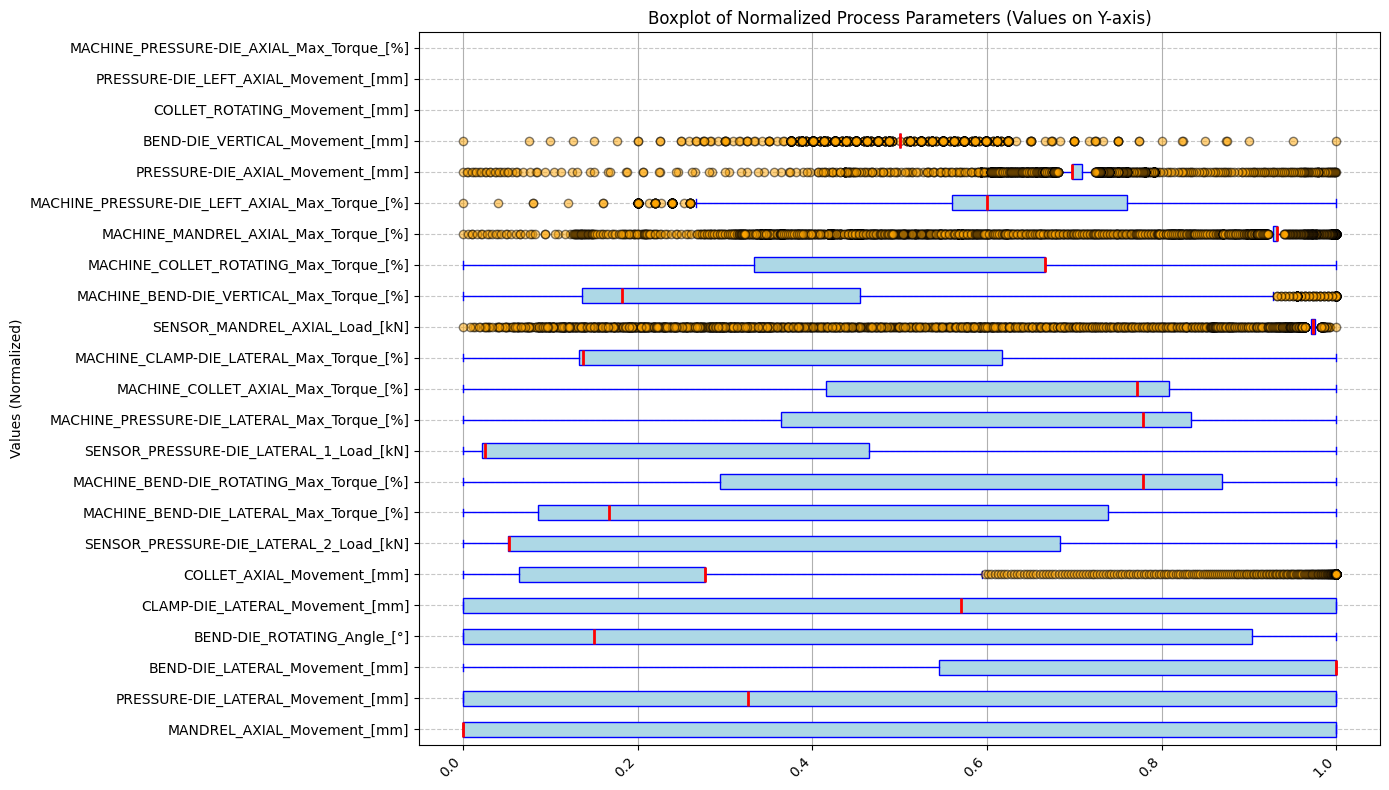

In [13]:
import matplotlib.pyplot as plt

# Sort columns by variance
variances = df_process_parameters_norm.var().sort_values(ascending=False)
sorted_cols = variances.index

plt.figure(figsize=(14, 8))
df_process_parameters_norm[sorted_cols].boxplot(
    vert=False,              # values on Y-axis
    patch_artist=True,      # enable colors
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker='o', markerfacecolor='orange', alpha=0.5)
)

plt.title("Boxplot of Normalized Process Parameters (Values on Y-axis)")
plt.ylabel("Values (Normalized)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Construct geometry data frame

In [14]:
df_geometry_data = experiment_as_dictinary['geometry_data_key_characteristics_arc'].drop(columns= ['Tube_Section'])
df_geometry_data.index = df_geometry_data['Angle[degree]ORDistance[mm]']
df_geometry_data.drop(columns=['Angle[degree]ORDistance[mm]'], inplace=True)
df_geometry_data = df_geometry_data.apply(pd.to_numeric, errors='coerce')
df_geometry_data.tail()

,Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
Angle[degree]ORDistance[mm],,,,
41.00,22.150528,21.334929,0.037020,-0.696629
42.00,22.144354,21.339386,0.036537,-0.692172
43.00,22.135644,21.339377,0.036142,-0.692181
44.00,22.128793,21.341037,0.035756,-0.690521
44.71,22.127360,21.345171,0.035503,-0.686387


# Plot and normalize

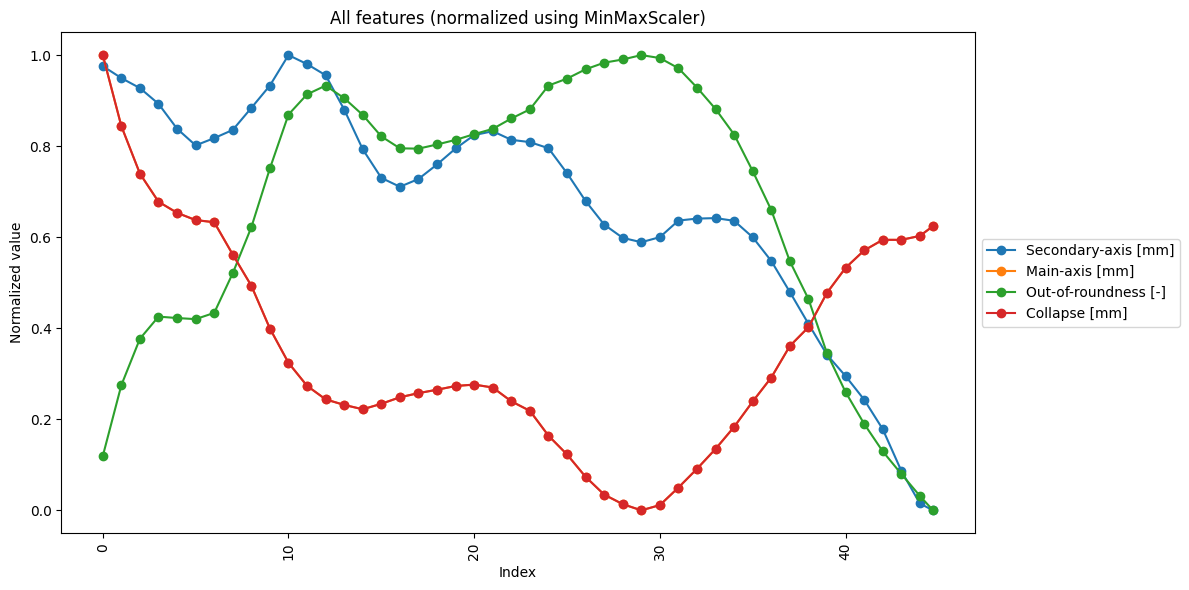

In [15]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
df_geometry_data_norm = pd.DataFrame(
    scaler.fit_transform(df_geometry_data),
    columns=df_geometry_data.columns,
    index=df_geometry_data.index
)

plt.figure(figsize=(12, 6))

# Plot all columns in one figure
for col in df_geometry_data_norm.columns:
    plt.plot(df_geometry_data_norm.index, df_geometry_data_norm[col], marker="o", label=col)

plt.title("All features (normalized using MinMaxScaler)")
plt.xlabel("Index")
plt.ylabel("Normalized value")
plt.xticks(rotation=90)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))  # legend outside
plt.tight_layout()
plt.show()

# See the statistical property(Variance)

In [17]:
df_geometry_data.var().sort_values()

Out-of-roundness [-]    0.000006
Secondary-axis [mm]     0.000610
Collapse [mm]           0.002125
Main-axis [mm]          0.002125
dtype: float64

In [18]:
df_geometry_data_norm.var().sort_values()

Collapse [mm]           0.057791
Main-axis [mm]          0.057791
Secondary-axis [mm]     0.067192
Out-of-roundness [-]    0.094147
dtype: float64

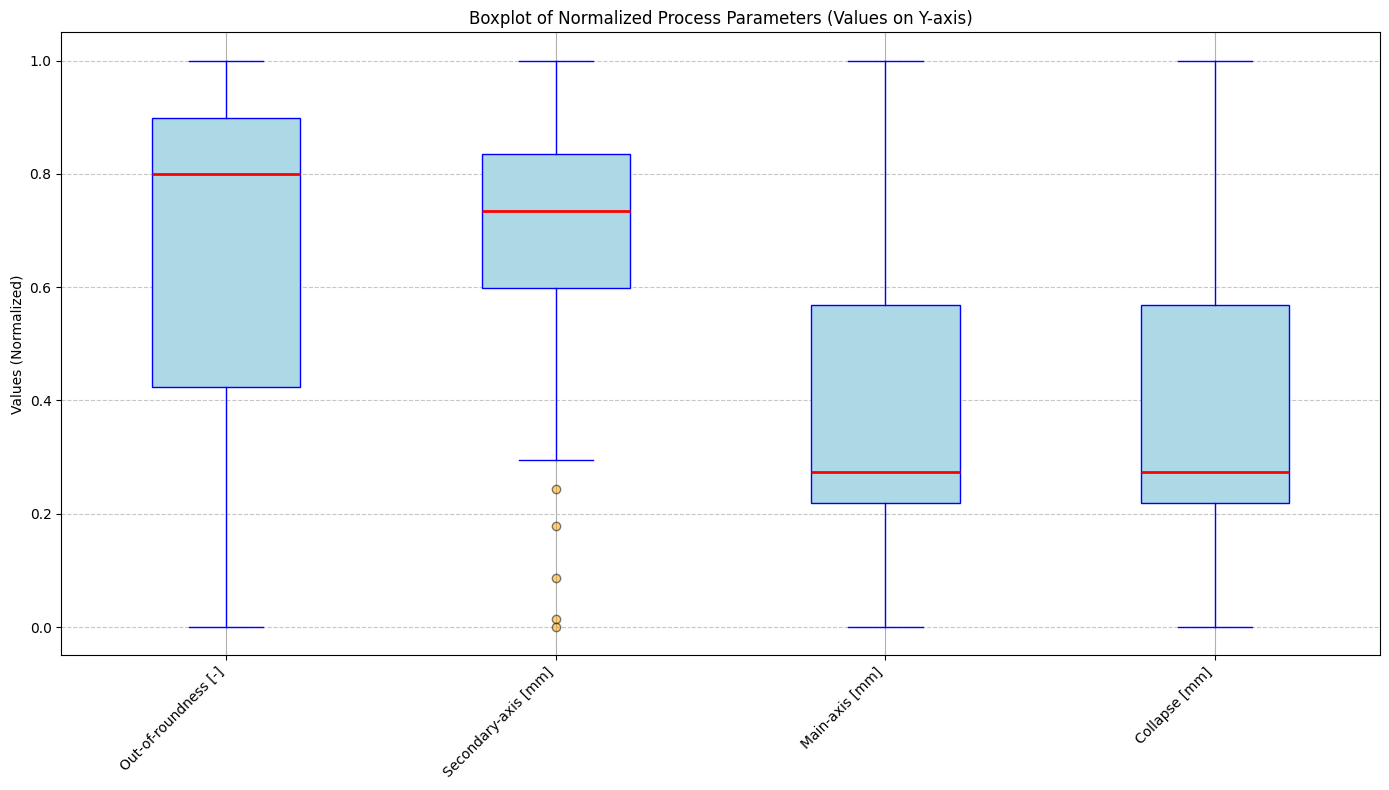

In [19]:
import matplotlib.pyplot as plt

# Sort columns by variance
variances = df_geometry_data_norm.var().sort_values(ascending=False)
sorted_cols = variances.index

plt.figure(figsize=(14, 8))
df_geometry_data_norm[sorted_cols].boxplot(
    vert=True,              # values on Y-axis
    patch_artist=True,      # enable colors
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker='o', markerfacecolor='orange', alpha=0.5)
)

plt.title("Boxplot of Normalized Process Parameters (Values on Y-axis)")
plt.ylabel("Values (Normalized)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Align windows in two data set

In [20]:
def plot_highlight_parts_list(dfs, parts, part_idx):
    part_idx = part_idx-1
    n = len(dfs)
    fig, axes = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=False)

    if n == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors

    for ax, df_num in zip(axes, dfs):
        splits = np.array_split(df_num.index, parts)

        if part_idx < 0 or part_idx >= parts:
            raise ValueError(f"part_idx must be between 1 and {parts}")

        selected_idx = splits[part_idx]
        selected = df_num.loc[selected_idx]

        # Plot all gray lines at once
        ax.plot(df_num.index, df_num.values, color="gray", linewidth=1, zorder=1)

        # Rectangle boundaries
        x_min, x_max = selected.index.min(), selected.index.max()
        y_min, y_max = df_num.min().min(), df_num.max().max()

        rect = Rectangle((x_min, y_min),
                         x_max - x_min,
                         y_max - y_min,
                         linewidth=0,
                         facecolor="red",
                         alpha=0.2,
                         zorder=0)
        ax.add_patch(rect)

        # Plot selected colored lines
        lines = ax.plot(selected.index, selected.values, linewidth=2, zorder=2)
        # Set colors and create legend entries
        for i, line in enumerate(lines):
            line.set_color(colors[i % 10])
        
        ax.set_ylabel("Values")
        ax.set_title(f"Highlighted Part {part_idx+1} of {parts}")
        ax.grid(True)
        
        # Create legend with column names
        ax.legend(lines, df_num.columns.tolist(), bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[-1].set_xlabel("Index")
    plt.tight_layout()
    plt.show()

    # return [df.loc[np.array_split(df.index, parts)[part_idx]] for df in dfs]  # return selected parts


In [40]:
y = df_geometry_data_norm['Collapse [mm]'] #.loc[angle]  #'Collapse [mm]'

# Make sure features and target are aligned in time or index
X = df_process_parameters_norm.copy()  # shape (n_samples, n_features)

print(f"y shape: {y.shape}\nX shape: {X.shape}")

y shape: (46,)
X shape: (8562, 23)


In [41]:
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

# Build index for y (original positions)
orig_idx = np.linspace(0, len(X) - 1, num=len(y))

# Build new index for X (expanded positions)
new_idx = np.arange(len(X))

# Fit a B-spline interpolator
spline = make_interp_spline(orig_idx, y.values, k=5)  # k=3 → cubic B-spline

# Interpolate to match X length
y_expanded = spline(new_idx)

# Trim X to match (should align now)
X_trimmed = X.iloc[:len(y_expanded)]

print(X_trimmed.shape, y_expanded.shape)


(8562, 23) (8562,)


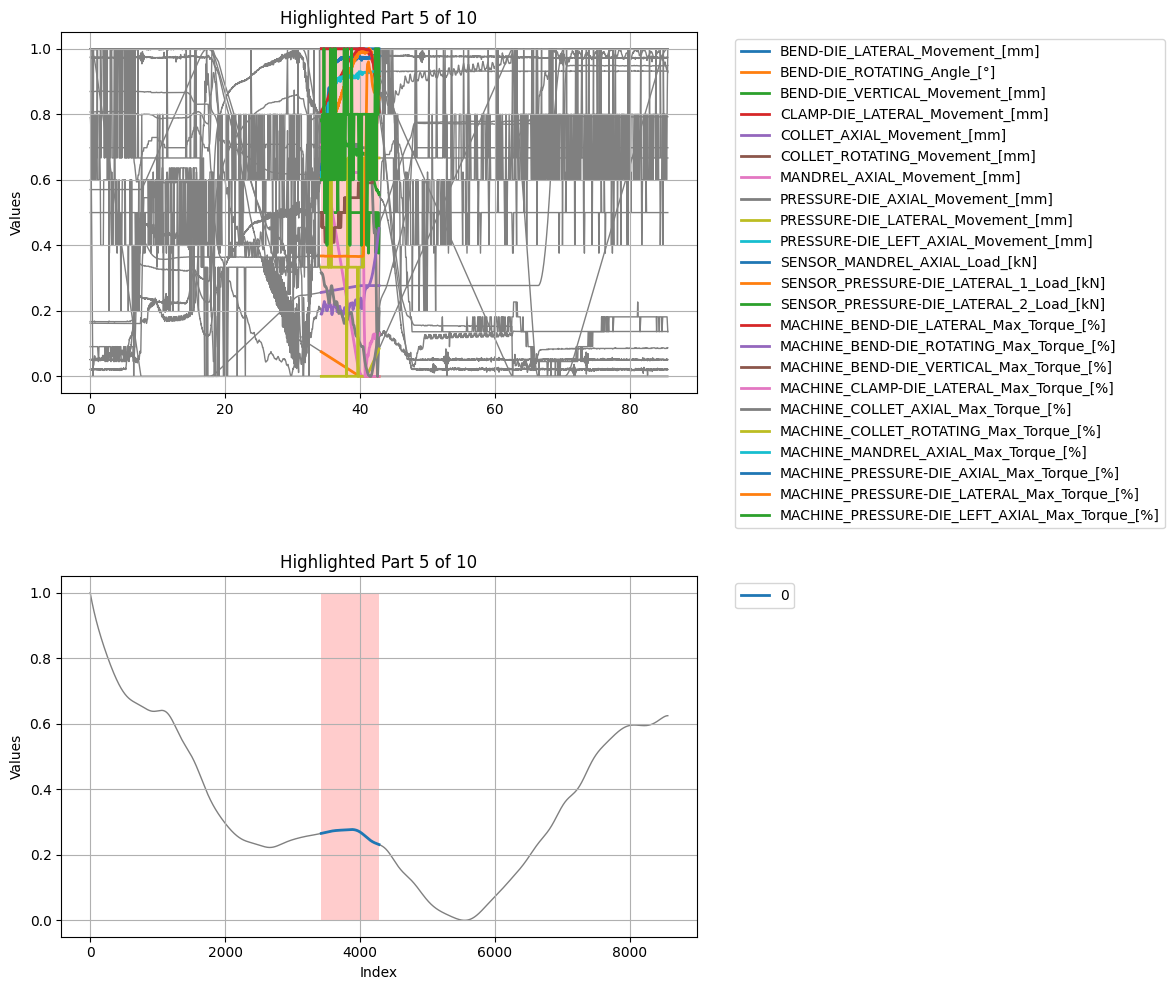

In [84]:
plot_highlight_parts_list(dfs=[pd.DataFrame(X_trimmed), pd.DataFrame(y_expanded)], parts = 10, part_idx=5)

Test MSE: 0.0000

Target 0 XGBoost feature importance (gain):


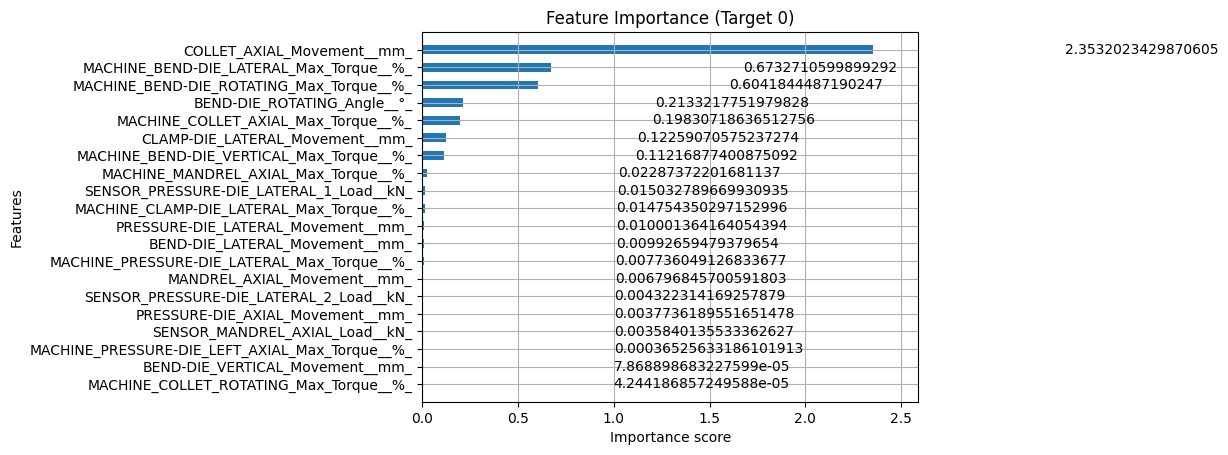


Target 1 XGBoost feature importance (gain):


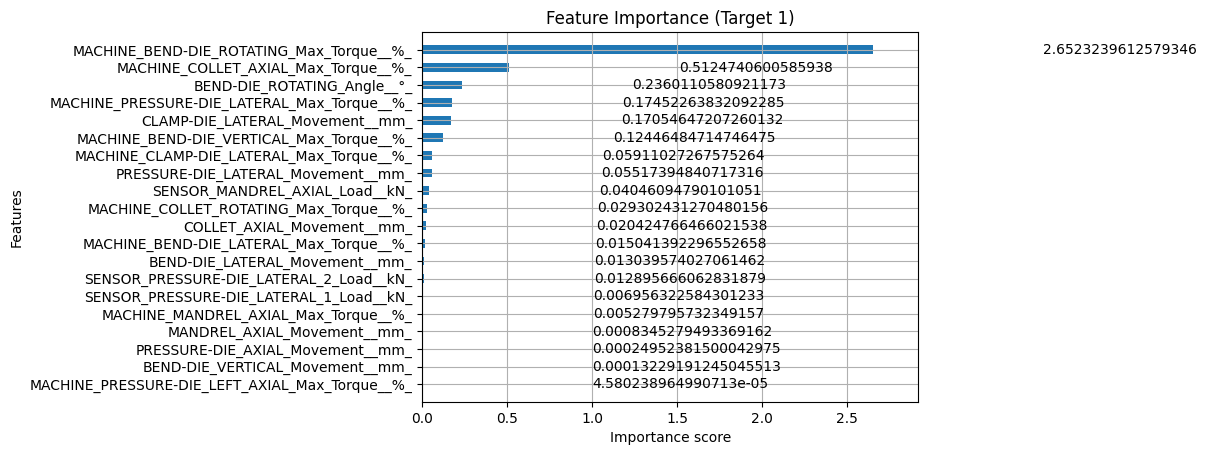


Target 2 XGBoost feature importance (gain):


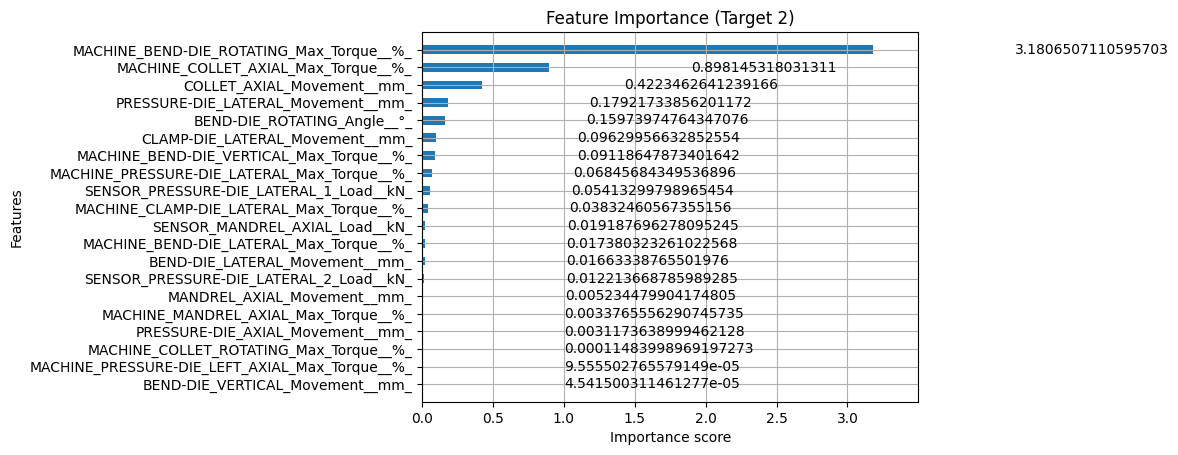


Target 3 XGBoost feature importance (gain):


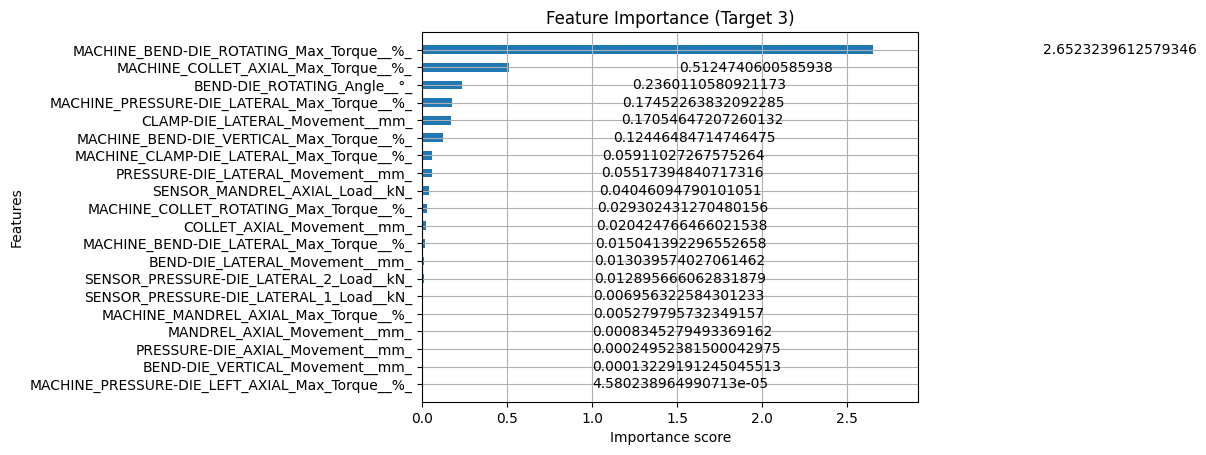


Target 0 permutation importance:


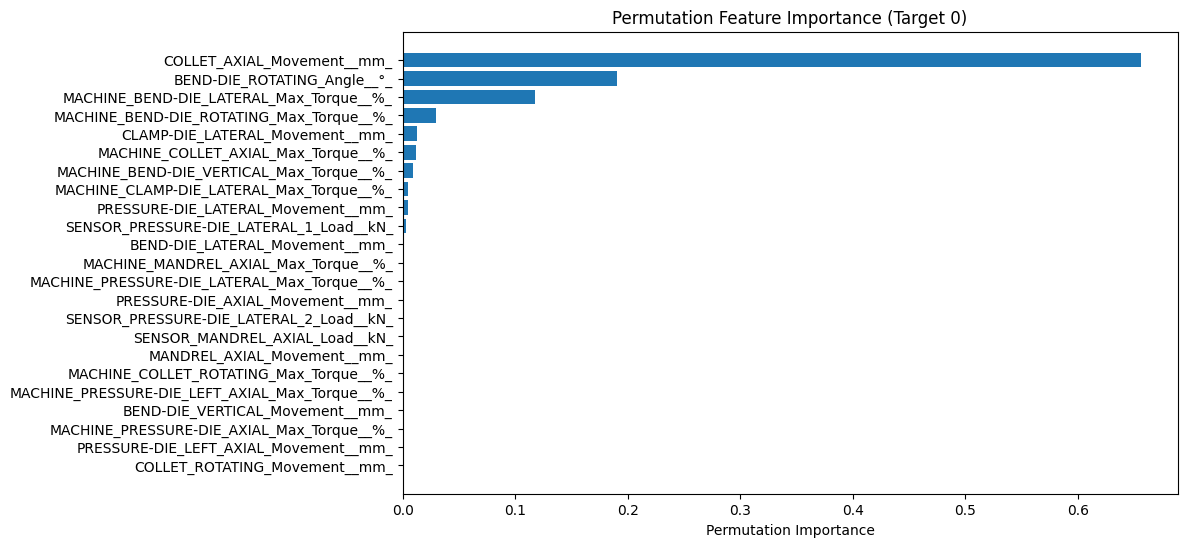


Target 1 permutation importance:


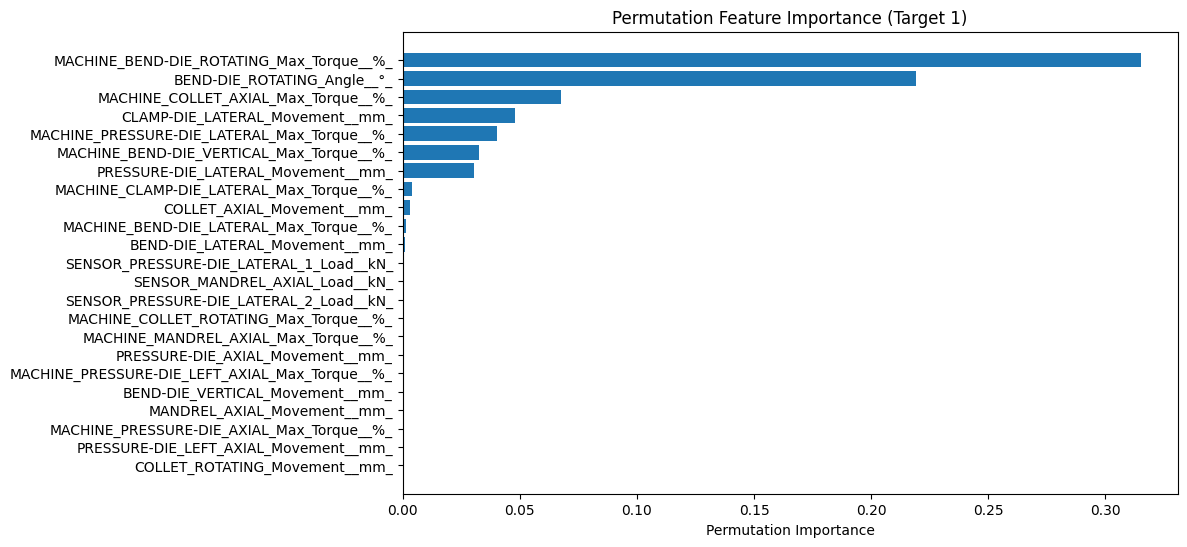


Target 2 permutation importance:


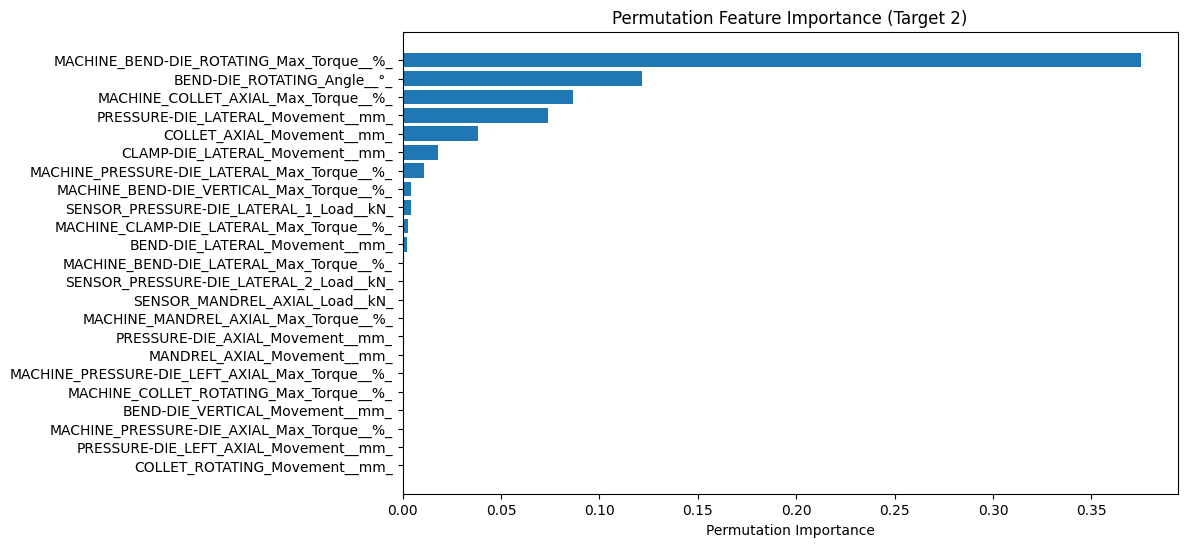


Target 3 permutation importance:


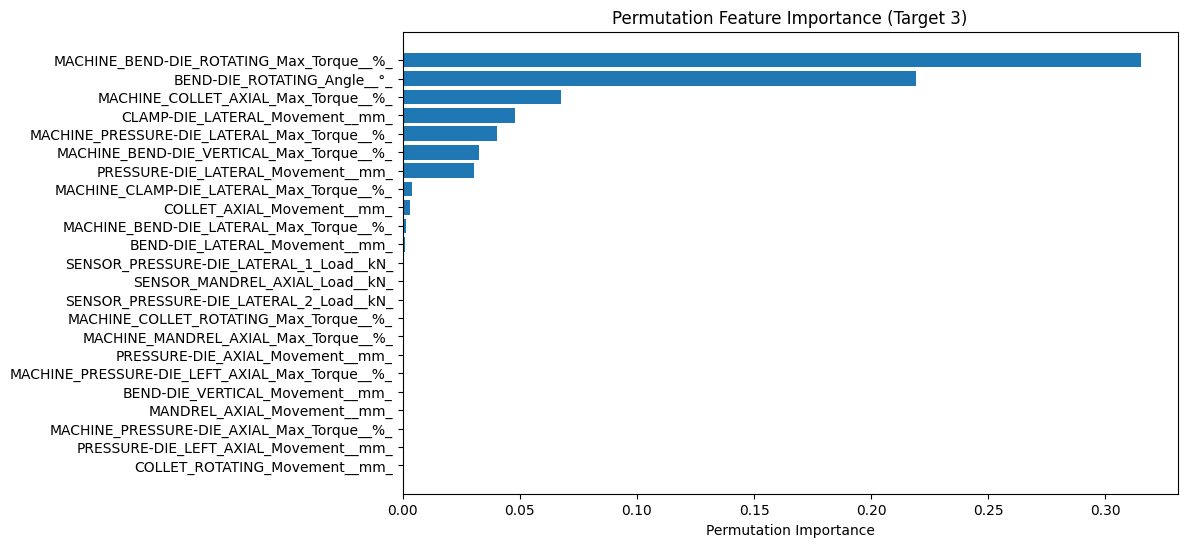


Target 0 SHAP values:


 99%|===================| 1690/1713 [00:26<00:00]        

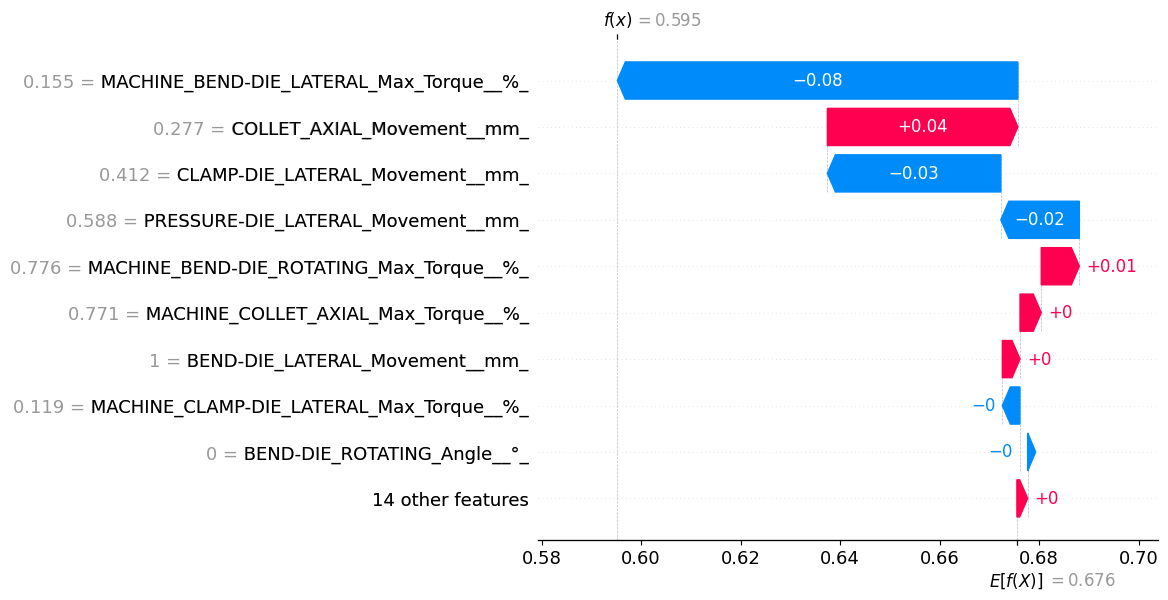


Target 1 SHAP values:


 97%|=================== | 1668/1713 [00:27<00:00]       

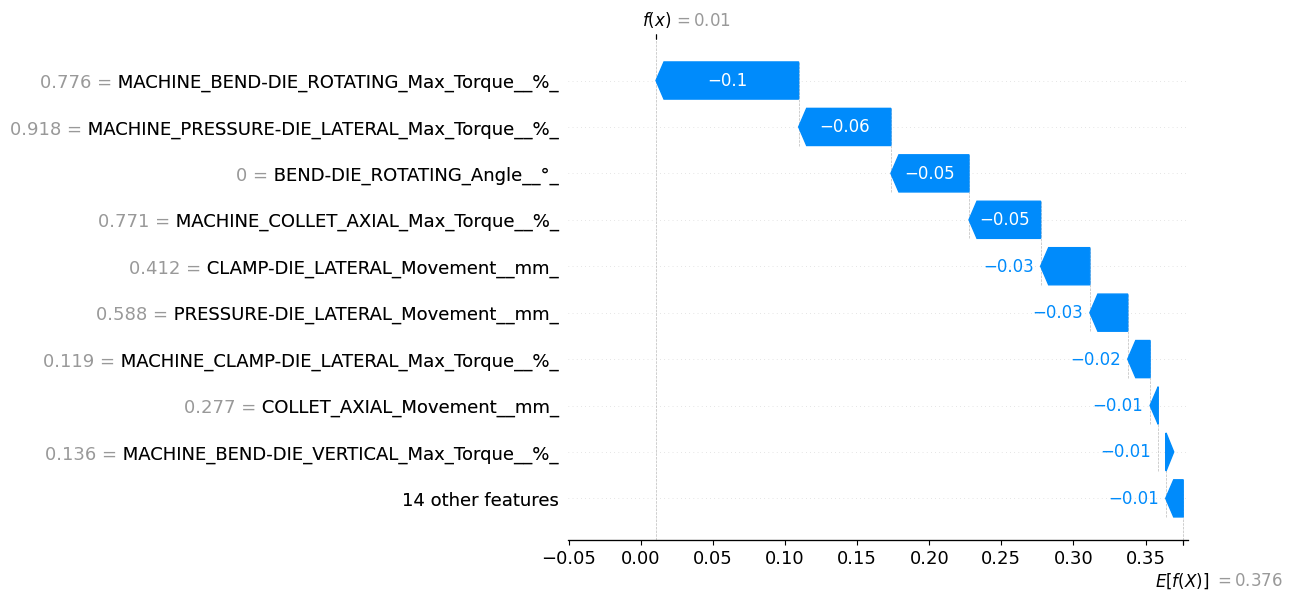


Target 2 SHAP values:


 99%|===================| 1702/1713 [00:29<00:00]        

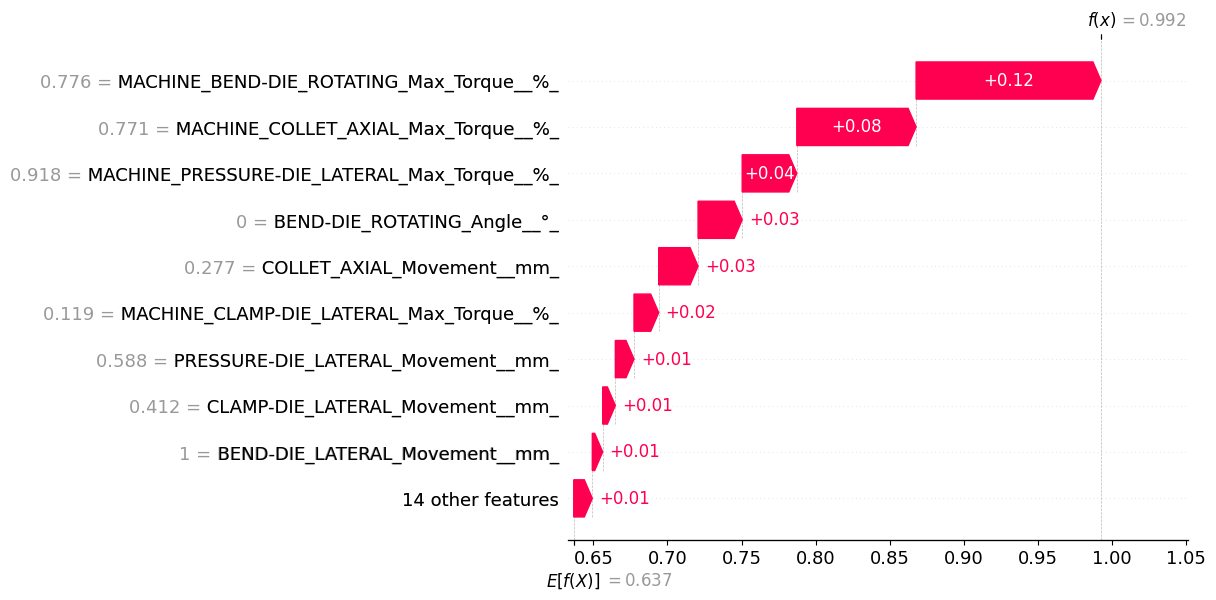


Target 3 SHAP values:


 98%|===================| 1681/1713 [00:28<00:00]        

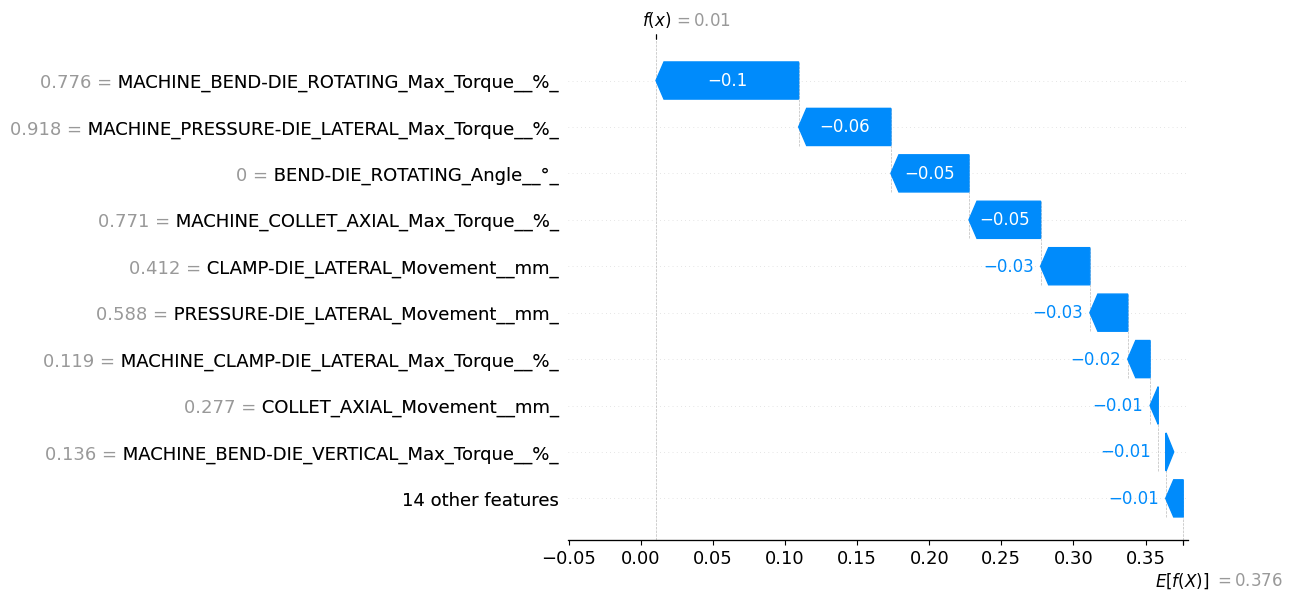

In [32]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

# --- Prepare data ---
X_safe = X_trimmed.copy()
X_safe.columns = [
    c.replace("[", "_").replace("]", "_").replace("<", "_").replace(":", "_").replace(" ", "_")
    for c in X_safe.columns
]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_safe, y_expanded, test_size=0.2, random_state=42
)

# --- Train multi-output XGBoost ---
model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
))
model.fit(X_train, y_train)

# --- Predict & evaluate ---
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

# ====================================================
# --- Method 1: XGBoost built-in feature importance ---
# ====================================================
for i, est in enumerate(model.estimators_):
    print(f"\nTarget {i} XGBoost feature importance (gain):")
    xgb.plot_importance(est, importance_type="gain", height=0.5, max_num_features=20)
    plt.title(f"Feature Importance (Target {i})")
    plt.show()

# ====================================================
# --- Method 2: Permutation Importance (sklearn) -----
# ====================================================
for i, est in enumerate(model.estimators_):
    print(f"\nTarget {i} permutation importance:")
    perm_importance = permutation_importance(est, X_test, y_test[:, i], n_repeats=10, random_state=42)
    sorted_idx = perm_importance.importances_mean.argsort()[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(X_test.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.title(f"Permutation Feature Importance (Target {i})")
    plt.gca().invert_yaxis()
    plt.show()

# ====================================================
# --- Method 3: SHAP Values (global + local) ---------
# ====================================================
for i, est in enumerate(model.estimators_):
    print(f"\nTarget {i} SHAP values:")
    explainer = shap.Explainer(est, X_train)
    shap_values = explainer(X_test)

    # Local explanation: first sample
    shap.plots.waterfall(shap_values[0])


# Mean absolute SHAP values
# shap_abs_mean = pd.DataFrame({
#     'Feature': X_test.columns,
#     'Mean_ABS_SHAP': np.abs(shap_values.values).mean(axis=0)
# }).sort_values(by='Mean_ABS_SHAP', ascending=False)

# print("\nFeature effect (mean absolute SHAP value) ranking:")
# for i, row in enumerate(shap_abs_mean.itertuples(), 1):
#     print(f"{i}. {row.Feature}: {row.Mean_ABS_SHAP:.4f}")

# # Bar plot
# plt.figure(figsize=(10, 6))
# plt.barh(shap_abs_mean['Feature'], shap_abs_mean['Mean_ABS_SHAP'], color='skyblue')
# plt.gca().invert_yaxis()
# plt.xlabel('Mean Absolute SHAP Value')
# plt.title('Feature Importance (SHAP)')
# plt.show()

# # SHAP summary plot (global explanation)
# shap.summary_plot(shap_values, X_test)

# # SHAP dependence plot (example for top feature)
# top_feature = shap_abs_mean.iloc[0]['Feature']
# shap.dependence_plot(top_feature, shap_values.values, X_test)

# # SHAP decision plot (example for one instance)
# shap.decision_plot(explainer.expected_value, shap_values.values[0, :], X_test.iloc[0, :])


In [ ]:
X_safe, y_expanded.shape

(8562, 23)

Using model: xgboost
Model MAE: 0.0006
Model R²: 1.0000


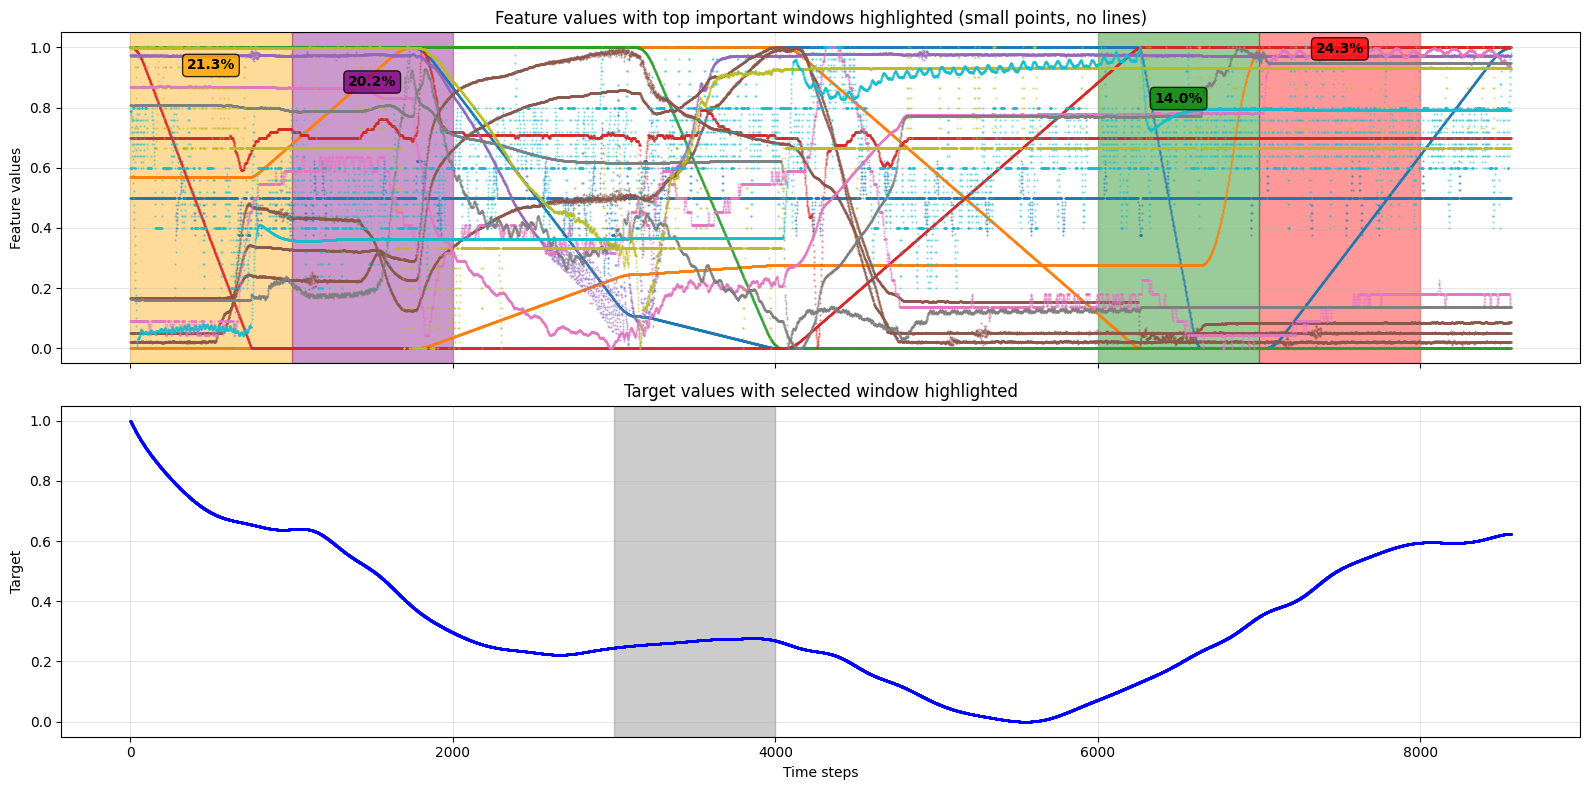

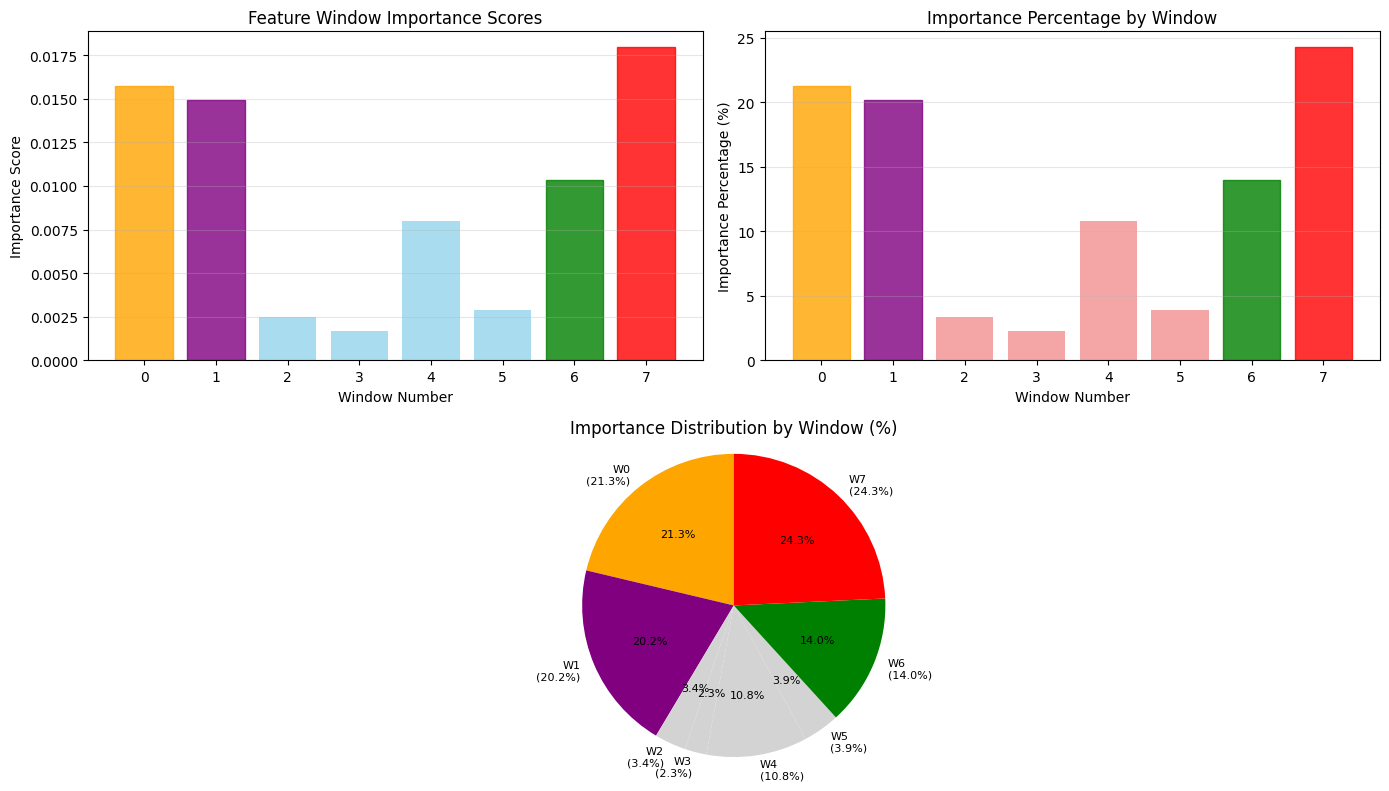

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
# ---------------------------
# 2. Define Configs
# ---------------------------
window_size = 1000
method_num = 1  # 1 = permutation importance, 2 = MDI
num_top_windows = 4  # Change this to get more or fewer top windows
target_window_idx = 3
model_choice = 'xgboost'

# Ensure X is a numpy array for simpler indexing
X = np.array(X_safe)
y = np.array(y_expanded)
n_timesteps = len(y)
n_features = X.shape[1]

n_feature_windows = n_timesteps // window_size
target_start = target_window_idx * window_size
target_end = target_start + window_size
target_window = y[target_start:target_end]

# ---------------------------
# 3. Choose and fit model
# ---------------------------
models = {
    "random_forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "gradient_boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "xgboost": XGBRegressor(n_estimators=100, random_state=42),
    "lightgbm": LGBMRegressor(n_estimators=100, random_state=42),
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=1.0),
    "lasso": Lasso(alpha=0.1),
    "elasticnet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "svr": SVR(kernel='rbf', C=1.0),
    "mlp": MLPRegressor(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000),
    "adaboost": AdaBoostRegressor(n_estimators=100, random_state=42)
}

if model_choice not in models:
    print(f"Model {model_choice} not found. Using random_forest instead.")
    model_choice = "random_forest"

model = models[model_choice]
model.fit(X, y)

# Evaluate model performance
y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Using model: {model_choice}")
print(f"Model MAE: {mae:.4f}")
print(f"Model R²: {r2:.4f}")

# ---------------------------
# 4. Compute feature window importance
# ---------------------------
feature_window_importance = []

match method_num:
    case 1:
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size

            X_perm = X.copy()
            for f in range(n_features):
                X_perm[start:end, f] = np.random.permutation(X_perm[start:end, f])

            y_hat = model.predict(X_perm)
            imp = np.mean(np.abs(y - y_hat))
            feature_window_importance.append(imp)
    case 2:
        mdi_importance = model.feature_importances_
        for w in range(n_feature_windows):
            feature_window_importance.append(np.sum(mdi_importance))

# ---------------------------
# 5. Calculate importance percentages and find top windows
# ---------------------------
total_importance = np.sum(feature_window_importance)
importance_percentages = (np.array(feature_window_importance) / total_importance) * 100

top_window_indices = np.argsort(feature_window_importance)[-num_top_windows:][::-1]

for i, window_idx in enumerate(top_window_indices):
    importance = feature_window_importance[window_idx]
    percentage = importance_percentages[window_idx]
    start_time = window_idx * window_size
    end_time = start_time + window_size

# ---------------------------
# 6. Plot with multiple important windows highlighted ON TOP of feature values
# ---------------------------
timesteps = np.arange(n_timesteps)
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Use a colormap that can handle any number of features
colors = plt.cm.tab10(np.linspace(0, 1, n_features))

# Plot features with smaller points and no lines
for f in range(n_features):
    axes[0].plot(timesteps, X[:, f], marker='.', markersize=1, color=colors[f], 
                linestyle='', alpha=0.6, label=f'Feature {f+1}')

# Highlight top important windows with different colors (ON TOP of the features)
highlight_colors = ['red', 'orange', 'purple', 'green', 'brown', 'cyan', 'magenta', 'yellow']
for i, window_idx in enumerate(top_window_indices):
    if i < len(highlight_colors):
        feature_start = window_idx * window_size
        feature_end = feature_start + window_size
        
        # Create semi-transparent rectangles for better visibility
        axes[0].axvspan(feature_start, feature_end, 
                       color=highlight_colors[i], alpha=0.4, 
                       label=f'Top {i+1} window ({importance_percentages[window_idx]:.1f}%)')
        
        # Add text annotation for each window
        mid_point = (feature_start + feature_end) / 2
        y_range = axes[0].get_ylim()
        text_y = y_range[1] - 0.05 * (y_range[1] - y_range[0]) * (i + 1)
        axes[0].text(mid_point, text_y, f'{importance_percentages[window_idx]:.1f}%',
                    ha='center', va='center', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=highlight_colors[i], alpha=0.8))

axes[0].set_ylabel("Feature values")
axes[0].set_title("Feature values with top important windows highlighted (small points, no lines)")
#axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot target with smaller points
axes[1].plot(timesteps, y, marker='.', markersize=2, color='blue', 
            linestyle='-', alpha=0.8, linewidth=0.5, label='Target values')
axes[1].axvspan(target_start, target_end, color='grey', alpha=0.4, label='Selected target window')
axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Target")
axes[1].set_title("Target values with selected window highlighted")
#axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: Show the importance values for all windows
plt.figure(figsize=(14, 8))

# Bar chart with importance values
plt.subplot(2, 2, 1)
bars = plt.bar(range(n_feature_windows), feature_window_importance, color='skyblue', alpha=0.7)
plt.xlabel('Window Number')
plt.ylabel('Importance Score')
plt.title('Feature Window Importance Scores')
plt.xticks(range(n_feature_windows))
plt.grid(axis='y', alpha=0.3)

# Highlight top windows in bar chart
for i, window_idx in enumerate(top_window_indices):
    if i < len(highlight_colors):
        bars[window_idx].set_color(highlight_colors[i])
        bars[window_idx].set_alpha(0.8)

# Bar chart with percentages
plt.subplot(2, 2, 2)
bars_pct = plt.bar(range(n_feature_windows), importance_percentages, color='lightcoral', alpha=0.7)
plt.xlabel('Window Number')
plt.ylabel('Importance Percentage (%)')
plt.title('Importance Percentage by Window')
plt.xticks(range(n_feature_windows))
plt.grid(axis='y', alpha=0.3)

# Highlight top windows in percentage chart
for i, window_idx in enumerate(top_window_indices):
    if i < len(highlight_colors):
        bars_pct[window_idx].set_color(highlight_colors[i])
        bars_pct[window_idx].set_alpha(0.8)

# Pie chart showing percentage distribution
plt.subplot(2, 2, (3, 4))
# Create labels with both window number and percentage
labels = [f'W{w}\n({importance_percentages[w]:.1f}%)' for w in range(n_feature_windows)]
colors_pie = ['lightgray'] * n_feature_windows
# Highlight top windows in pie chart
for i, window_idx in enumerate(top_window_indices):
    if i < len(highlight_colors):
        colors_pie[window_idx] = highlight_colors[i]

wedges, texts, autotexts = plt.pie(importance_percentages, labels=labels, colors=colors_pie, 
                                  autopct='%1.1f%%', startangle=90, labeldistance=1.1)
plt.axis('equal')
plt.title('Importance Distribution by Window (%)')

# Make text smaller for better readability
for text in texts + autotexts:
    text.set_fontsize(8)

plt.tight_layout()
plt.show()
